# OCPM analysis
In this notebook, we analyse the generated OCELs using OCPM and our novel split-tree-mining approach

In [45]:
import pm4py
import pandas as pd
import os, json
from collections import defaultdict

In [46]:
class Split_tree:
    def __init__(self,root):
        self.root = root
        self.nodes = [root]
        self.leaves = []
        self.splits = 0
    
    

## Combine traces to coherent OCEL

In [47]:
complete_ocel_json = {}
complete_ocel_json["objects"] = []
complete_ocel_json["events"] =[]
o_count = 0
path = "../Output/"
json_files = [pos_json for pos_json in os.listdir(path) if pos_json.endswith('.json')]
with open(os.path.join(path,json_files[0])) as init_js:
    json_text = json.load(init_js)
    complete_ocel_json["objectTypes"]= json_text["objectTypes"]
    complete_ocel_json["eventTypes"]= json_text["eventTypes"]

for index, js in enumerate(json_files):
    with open(os.path.join(path, js)) as json_file:
        json_ocel = json.load(json_file)
        o_count += len(json_ocel["objects"])
        complete_ocel_json["objects"] +=(json_ocel["objects"])
        complete_ocel_json["events"]+=(json_ocel["events"])

# Serializing json
json_object = json.dumps(complete_ocel_json)

# Writing to sample.json
with open("OCEL.json", "w") as outfile:
    outfile.write(json_object)

In [48]:
ocel = pm4py.read_ocel2_json("OCEL.json")

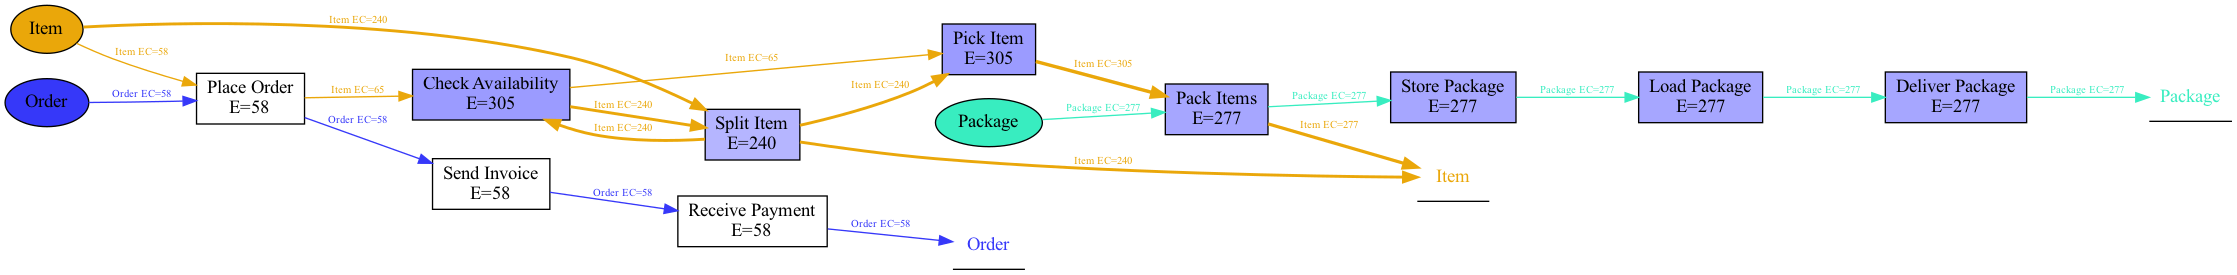

In [49]:
pm4py.view_ocdfg(pm4py.discover_ocdfg(ocel))

## Mine Split trees

1. initialize all items as not visited
2. find all roots via order placed
2. initialise graph for each root
3. get list of all split events
4. iterate over splits, marking item as visited and adding them to queue while adding edges


In [50]:
items = ocel.objects[ocel.objects['ocel:type']=="Item"]["ocel:oid"].unique()
order_placed = pm4py.filter_ocel_event_attribute(ocel,'ocel:activity',['Place Order'])

nested_roots = order_placed.get_extended_table()["ocel:type:Item"].tolist()
roots = []
for nested_root in nested_roots:
    for root in nested_root:
        roots.append(root)

split_df = pm4py.filter_ocel_event_attribute(ocel,'ocel:activity',['Split Item']).get_extended_table()
split_parents = ocel.relations[(ocel.relations["ocel:activity"]=="Split Item") & (ocel.relations["ocel:qualifier"]=="Split of available items for delivery")]
split_trees={}

for root in roots:
    split_trees[root]=(Split_tree(root))

In [42]:
split_df

,ocel:eid,ocel:timestamp,ocel:activity,company,payment_method,checker,picker,packer,storer,loader,logistics_company,spliter,ocel:type:Item
0,e_6_0_5_company_1_1,2025-08-06 08:47:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S. Wilson,"[item_6_1, item_6_1_7572, item_6_1_4783]"
1,e_7_0_5_company_1_1,2025-08-22 08:47:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D. Brown,"[item_7_1, item_7_1_7068, item_7_1_5651]"
2,e_18_0_5_company_1_1,2025-12-26 08:22:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L. Moore,"[item_18_1_2896, item_18_1_5456, item_18_1]"
3,e_18_1_5_company_1_1,2025-12-31 09:01:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E. Davis,"[item_18_1_9778, item_18_1_5456, item_18_1_1693]"
4,e_29_0_5_company_1_1,2026-05-22 09:02:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S. Wilson,"[item_29_1, item_29_1_2598, item_29_1_8402]"
5,e_32_0_5_company_1_0,2026-06-30 09:04:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E. Davis,"[item_32_0, item_32_0_1229, item_32_0_4485]"
6,e_39_0_5_company_1_0,2026-09-24 08:11:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D. Brown,"[item_39_0_6962, item_39_0, item_39_0_2408]"
7,e_43_0_5_company_1_1,2026-11-08 08:56:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L. Moore,"[item_43_1, item_43_1_6254, item_43_1_7310]"
8,e_60_0_5_company_1_1,2027-06-05 08:25:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O. Garcia,"[item_60_1_4588, item_60_1, item_60_1_5471]"
9,e_63_0_5_company_1_1,2027-07-18 08:12:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O. Garcia,"[item_63_1, item_63_1_6354, item_63_1_5380]"


In [31]:
roots

['item_0_0',
 'item_1_1',
 'item_2_1',
 'item_3_0',
 'item_4_1',
 'item_5_0',
 'item_6_1',
 'item_7_1',
 'item_8_0',
 'item_9_1',
 'item_10_0',
 'item_11_1',
 'item_13_0',
 'item_14_1',
 'item_15_0',
 'item_16_1',
 'item_17_0',
 'item_18_1',
 'item_19_1',
 'item_20_0',
 'item_21_1',
 'item_22_0',
 'item_23_1',
 'item_24_1',
 'item_25_0',
 'item_26_1',
 'item_27_0',
 'item_28_1',
 'item_29_1',
 'item_30_0',
 'item_31_1',
 'item_32_0',
 'item_33_1',
 'item_34_1',
 'item_35_0',
 'item_36_1',
 'item_37_0',
 'item_38_1',
 'item_39_0',
 'item_40_1',
 'item_41_1',
 'item_42_0',
 'item_43_1',
 'item_44_0',
 'item_45_1',
 'item_46_1',
 'item_47_0',
 'item_48_1',
 'item_49_0',
 'item_50_1',
 'item_51_0',
 'item_52_1',
 'item_53_1',
 'item_54_0',
 'item_55_1',
 'item_56_0',
 'item_57_1',
 'item_58_1',
 'item_59_0',
 'item_60_1',
 'item_61_0',
 'item_62_1',
 'item_63_1',
 'item_64_0',
 'item_65_1',
 'item_66_0',
 'item_67_1',
 'item_68_0',
 'item_69_1',
 'item_70_1',
 'item_71_0',
 'item_72_1',
 '

In [30]:
split_parents["ocel:oid"]

300          item_6_1
650          item_7_1
925         item_18_1
934    item_18_1_5456
549         item_29_1
759         item_32_0
430         item_39_0
408         item_43_1
355         item_60_1
235         item_63_1
629         item_68_0
82          item_74_1
Name: ocel:oid, dtype: string

In [59]:
for root in roots:
    queue = [root]
    if root == "item_6_1":
        print("here")
    while queue:
        current = queue.pop(0)
        if current in split_parents["ocel:oid"].copy().to_numpy():
            split_id = split_parents[split_parents["ocel:oid"]==current]["ocel:eid"].to_numpy()[0]
            split = split_df[split_df["ocel:eid"]==split_id]["ocel:type:Item"].to_numpy()[0]
            split.remove(current)
            split_trees[root].nodes += split
            queue += split
            split_trees[root].splits += 1
        else:
            split_trees[root].leaves.append(current)


ValueError: list.remove(x): x not in list

In [58]:
for root in split_trees.keys():
    if split_trees[root].splits > 5:
        print(root)

item_20_1
item_34_0
item_49_0


In [57]:
split_trees['item_20_1'].leaves

['item_20_1_2956',
 'item_20_1_1024',
 'item_20_1_7584',
 'item_20_1_7357',
 'item_20_1_2978',
 'item_20_1_2271',
 'item_20_1_1795']

In [96]:
ocel.relations[ocel.relations["ocel:eid"]=="e_1_0_5_company_1_0"]

,ocel:eid,ocel:activity,ocel:timestamp,ocel:oid,ocel:type,ocel:qualifier
976,e_1_0_5_company_1_0,Split Item,2025-04-10 08:19:00+00:00,item_1_0_6861,Item,Split item out of stock
977,e_1_0_5_company_1_0,Split Item,2025-04-10 08:19:00+00:00,item_1_0,Item,Split of available items for delivery
978,e_1_0_5_company_1_0,Split Item,2025-04-10 08:19:00+00:00,item_1_0_5948,Item,Split item for delivery


In [87]:
pm4py.filter_ocel_event_attribute(ocel,'ocel:activity',['Split Item']).get_extended_table()

,ocel:eid,ocel:timestamp,ocel:activity,company,payment_method,checker,picker,packer,storer,loader,logistics_company,spliter,ocel:type:Item
0,e_6_0_5_company_1_1,2025-08-06 08:47:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S. Wilson,"[item_6_1, item_6_1_7572, item_6_1_4783]"
1,e_7_0_5_company_1_1,2025-08-22 08:47:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D. Brown,"[item_7_1, item_7_1_7068, item_7_1_5651]"
2,e_18_0_5_company_1_1,2025-12-26 08:22:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L. Moore,"[item_18_1_2896, item_18_1_5456, item_18_1]"
3,e_18_1_5_company_1_1,2025-12-31 09:01:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E. Davis,"[item_18_1_9778, item_18_1_5456, item_18_1_1693]"
4,e_29_0_5_company_1_1,2026-05-22 09:02:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S. Wilson,"[item_29_1, item_29_1_2598, item_29_1_8402]"
5,e_32_0_5_company_1_0,2026-06-30 09:04:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E. Davis,"[item_32_0, item_32_0_1229, item_32_0_4485]"
6,e_39_0_5_company_1_0,2026-09-24 08:11:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D. Brown,"[item_39_0_6962, item_39_0, item_39_0_2408]"
7,e_43_0_5_company_1_1,2026-11-08 08:56:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L. Moore,"[item_43_1, item_43_1_6254, item_43_1_7310]"
8,e_60_0_5_company_1_1,2027-06-05 08:25:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O. Garcia,"[item_60_1_4588, item_60_1, item_60_1_5471]"
9,e_63_0_5_company_1_1,2027-07-18 08:12:43+00:00,Split Item,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O. Garcia,"[item_63_1, item_63_1_6354, item_63_1_5380]"


## Analyse Processes

In [11]:
pm4py.discover_ocdfg(ocel)

{'activities': {'Check Availability',
  'Deliver Package',
  'Load Package',
  'Pack Items',
  'Pick Item',
  'Place Order',
  'Receive Payment',
  'Send Invoice',
  'Split Item',
  'Store Package'},
 'object_types': {'Item', 'Order', 'Package'},
 'edges': {'event_couples': {'Order': {('Place Order',
     'Send Invoice'): {('e_0_1_company_1',
      'e_0_2_company_1'), ('e_10_1_company_1', 'e_10_2_company_1'), ('e_11_1_company_1',
      'e_11_2_company_1'), ('e_12_1_company_1',
      'e_12_2_company_1'), ('e_13_1_company_1', 'e_13_2_company_1'), ('e_14_1_company_1',
      'e_14_2_company_1'), ('e_15_1_company_1',
      'e_15_2_company_1'), ('e_16_1_company_1', 'e_16_2_company_1'), ('e_17_1_company_1',
      'e_17_2_company_1'), ('e_18_1_company_1',
      'e_18_2_company_1'), ('e_19_1_company_1', 'e_19_2_company_1'), ('e_1_1_company_1',
      'e_1_2_company_1'), ('e_20_1_company_1',
      'e_20_2_company_1'), ('e_21_1_company_1', 'e_21_2_company_1'), ('e_22_1_company_1',
      'e_22_2_co